<a href="https://colab.research.google.com/github/YouriKaufmann/CVaR-Tool/blob/main/V2_EN_Climate_Stress_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [3]:
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Read the "Static Company Data" file
chemin_excel = '/content/drive/MyDrive/Stress Test Climatique/Analyses/2 - Sportswear/Final/Données Statiques Entreprises Sportswear- CVaR.xlsx'
df_companies = pd.read_excel(chemin_excel)

# 3. Verify the import
print(df_companies)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
           Name  Ticker  Scope_1_2  Scope_3  %_of_Green_Revenue  Pass_Through  \
0        Adidas  ADS.DE     187591  6236869                   0             0   
1          Puma  PUM.DE      46498  1515367                   0             0   
2          Nike     NKE     268712  8186965                   0             0   
3     Lululemon    LULU      39834  1608150                   0             0   
4    On Running    ONON       2571   440233                   0             0   
5  Under Armour     UAA      37327  1664398                   0             0   

   Scope_3_SBTi_Current  Scope_3_SBTi_Baseline  Carbon_Reduction_Plan_Scope_3  \
0               5248523                6665470                           0.42   
1               1263756                1609916                           0.33   
2               8186965                9219283              

In [4]:
import numpy as np
import yfinance as yf

# 1. Scenario Parameters
CARBON_PRICE_BASE = 0
CARBON_PRICE_TARGET = 95.47
GREEN_MARKET_GROWTH = 0
HORIZON = 10

def get_fx_rates_12m_avg():
    """
    Fetches 12-month average FX rates vs EUR from Yahoo Finance.
    Falls back to hardcoded rates if any fetch fails.

    Methodology: arithmetic mean of daily closing prices over the last 252 trading days.
    This smooths short-term volatility and improves reproducibility vs spot rates.

    Limitation: rates are fetched at execution time. Re-running on a different date
    will produce slightly different averages. Document the execution date alongside results.
    """
    import datetime
    pairs = {'USD': 'USDEUR=X', 'CHF': 'CHFEUR=X', 'GBP': 'GBPEUR=X'}
    fallback = {'USD': 0.855, 'CHF': 0.985, 'GBP': 1.13, 'EUR': 1.0}
    rates = {'EUR': 1.0}
    end = datetime.date.today()
    start = end - datetime.timedelta(days=365)
    for currency, ticker in pairs.items():
        try:
            data = yf.download(ticker, start=start, end=end, progress=False)
            avg = float(data['Close'].mean().iloc[0])
            rates[currency] = round(avg, 4)
            print(f"  {currency}/EUR 12m avg: {rates[currency]}")
        except Exception as e:
            rates[currency] = fallback[currency]
            print(f"  {currency}/EUR fallback used: {fallback[currency]} ({e})")
    return rates

print("Fetching 12-month average FX rates...")
CURRENCY_TO_EUR = get_fx_rates_12m_avg()
print(f"FX rates used: {CURRENCY_TO_EUR}")

# Constants for WACC calculation (update at each analysis date)
RISK_FREE_RATE = 0.0440      # US Treasury 10Y — Damodaran, May 2026
MARKET_RISK_PREMIUM = 0.0424 # Implied ERP — Damodaran, May 1, 2026
CORPORATE_TAX_RATE = 0.25   # Standard corporate tax rate

def calculate_wacc(info, conversion_rate):
    try:
        market_cap = info.get('marketCap', 0) * conversion_rate
        total_debt = info.get('totalDebt', 0) * conversion_rate
        total_capital = market_cap + total_debt
        if total_capital == 0:
            return 0.071
        weight_equity = market_cap / total_capital
        weight_debt = total_debt / total_capital
        beta = info.get('beta', 1.0)
        if beta is None or beta <= 0:
            beta = 1.0
        cost_of_equity = RISK_FREE_RATE + beta * MARKET_RISK_PREMIUM
        interest_expense = abs(info.get('interestExpense', 0)) * conversion_rate
        if total_debt > 0 and interest_expense > 0:
            cost_of_debt = max(0.02, min(interest_expense / total_debt, 0.15))
        else:
            cost_of_debt = 0.04
        wacc = (weight_equity * cost_of_equity) + (weight_debt * cost_of_debt * (1 - CORPORATE_TAX_RATE))
        return round(max(0.04, min(wacc, 0.20)), 4)
    except:
        return 0.071


def compute_scope3_reduction(scope3_total_current, scope3_sbti_current, scope3_sbti_baseline, reduction_plan):
    """
    Computes the effective Scope 3 reduction to apply on total current-year emissions,
    accounting for partial SBTi target coverage.

    Steps:
        1. target_2030_sbti   = scope3_sbti_baseline * (1 - reduction_plan)
        2. eff_reduction_sbti = 1 - (target_2030_sbti / scope3_sbti_current)
           (reduction within the SBTi perimeter only)
        3. coverage = scope3_sbti_current / scope3_total_current
           (share of total Scope 3 covered by the SBTi target)
        4. eff_reduction_total = eff_reduction_sbti * coverage
           (reduction applied to total Scope 3)

    --- WHY SCOPE 3 ONLY ---
    Carbon stress tests apply a carbon price to physical (location-based) emissions
    (EU ETS, CBAM, carbon taxes). SBTi Scope 1+2 targets are market-based (RECs, PPAs)
    and cannot be applied to location-based data without methodological inconsistency.
    Scope 3 is identical under both methods and is therefore the only applicable scope.
    Limitation: Scope 1+2 operational decarbonization is not captured in the with-plan
    run. To be revisited for carbon-intensive sectors (steel, cement, chemicals) where
    Scope 1+2 is material and location-based targets may exist.

    --- INTENSITY TARGET CONVERSION ---
    For intensity-based SBTi targets, excluded from the comparison du to impossibility of comparison vs absolute target.

    --- EXCEL INPUTS ---
    Col G  Scope_3_SBTi_Current   : Scope 3 within SBTi perimeter, current year (tCO2e)
    Col H  Scope_3_SBTi_Baseline  : Scope 3 within SBTi perimeter, baseline year (tCO2e)
    Col I  Carbon_Reduction_Plan_Scope_3 : reduction rate vs SBTi baseline (decimal)
                                           0 if no validated plan or plan withdrawn

    Returns: effective reduction rate on total Scope 3 (float, 0 to 1).
    Capped at 0 if SBTi emissions rose above baseline.
    """
    try:
        if pd.isna(scope3_sbti_baseline) or pd.isna(reduction_plan) or pd.isna(scope3_sbti_current):
            return 0.0
        if scope3_total_current <= 0 or scope3_sbti_current <= 0 or scope3_sbti_baseline <= 0:
            return 0.0
        target_2030_sbti = scope3_sbti_baseline * (1 - reduction_plan)
        eff_reduction_sbti = 1 - (target_2030_sbti / scope3_sbti_current)
        eff_reduction_sbti = max(0.0, eff_reduction_sbti)
        coverage = scope3_sbti_current / scope3_total_current
        return eff_reduction_sbti * coverage
    except:
        return 0.0


def calculate_cvar_and_sector(row, with_transition_plan=False):
    """
    Computes CVaR scores for a company.

    with_transition_plan=False : baseline run, current emissions unchanged.
    with_transition_plan=True  : applies declared Scope 3 reduction only.
                                 Scope 1+2 intentionally unchanged.
    """
    try:
        tk = yf.Ticker(row['Ticker'])
        info = tk.info

        extracted_sector = info.get('sector', 'Unknown')
        currency = info.get('currency', 'USD')
        conversion_rate = CURRENCY_TO_EUR.get(currency, 0.855)

        ebitda_override = row.get('EBITDA_Override', None)
        if pd.notna(ebitda_override) and ebitda_override > 0:
            ebitda = ebitda_override / conversion_rate
        else:
            ebitda = info.get('ebitda', 0)
        mkt_cap = info.get('marketCap', 0)

        if ebitda == 0 or mkt_cap == 0:
            return pd.Series([extracted_sector, None, None])

        currency = info.get('currency', 'USD')
        conversion_rate = CURRENCY_TO_EUR.get(currency, 0.855)

        scope_1_2 = row['Scope_1_2']  # location-based, unchanged in both runs
        scope_3 = row['Scope_3']

        if with_transition_plan:
            eff_red_3 = compute_scope3_reduction(
                scope3_total_current=scope_3,
                scope3_sbti_current=row.get('Scope_3_SBTi_Current', np.nan),
                scope3_sbti_baseline=row.get('Scope_3_SBTi_Baseline', np.nan),
                reduction_plan=row.get('Carbon_Reduction_Plan_Scope_3', np.nan)
            )
            scope_3 = scope_3 * (1 - eff_red_3)
            # Scope 1+2 unchanged: SBTi targets are market-based, incompatible
            # with location-based stress test (see compute_scope3_reduction docstring)

        total_emissions = scope_1_2 + scope_3
        gross_carbon_cost = total_emissions * (CARBON_PRICE_TARGET - CARBON_PRICE_BASE)
        transferred_amount = gross_carbon_cost * row['Pass_Through']
        annual_net_cost = gross_carbon_cost - transferred_amount

        annual_upside = ebitda * row['%_of_Green_Revenue'] * GREEN_MARKET_GROWTH
        delta_cf = annual_upside - annual_net_cost

        wacc = calculate_wacc(info, conversion_rate)
        pv_impact = sum([delta_cf / ((1 + wacc)**t) for t in range(1, HORIZON + 1)])

        cvar_score_mktcap = round((pv_impact / mkt_cap) * 100, 2)
        cvar_score_ebitda = round((pv_impact / ebitda) * 100, 2)

        return pd.Series([extracted_sector, cvar_score_mktcap, cvar_score_ebitda])

    except Exception as e:
        print(f"Erreur pour {row['Ticker']} : {type(e).__name__} — {e}")
        return pd.Series(['Error', None, None])

# 3. Execution
print("Run 1/2: Without transition plan (baseline)...")
df_companies[['Sector', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA']] = \
    df_companies.apply(lambda row: calculate_cvar_and_sector(row, with_transition_plan=False), axis=1)

df_without_plan = df_companies[['Name', 'Ticker', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA']].copy()
df_without_plan.columns = ['Name', 'Ticker', 'CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan']

print("Run 2/2: With transition plan (Scope 3 reduction applied)...")
df_companies[['Sector', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA']] = \
    df_companies.apply(lambda row: calculate_cvar_and_sector(row, with_transition_plan=True), axis=1)

df_with_plan = df_companies[['Name', 'Ticker', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA']].copy()
df_with_plan.columns = ['Name', 'Ticker', 'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan']

# Merge and compute delta
results_comparison = df_without_plan.merge(df_with_plan, on=['Name', 'Ticker'])
results_comparison['Delta_MktCap'] = (
    results_comparison['CVaR_MktCap_WithPlan'] - results_comparison['CVaR_MktCap_NoPlan']
)
results_comparison['Delta_EBITDA'] = (
    results_comparison['CVaR_EBITDA_WithPlan'] - results_comparison['CVaR_EBITDA_NoPlan']
)

results = df_companies[['Name', 'Ticker', 'Sector', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA']].sort_values(
    by='CVaR_Score_Mktcap', ascending=False
)
print(results_comparison)


Fetching 12-month average FX rates...


/tmp/ipykernel_9063/373757669.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end, progress=False)


  USD/EUR 12m avg: 0.8585
  CHF/EUR 12m avg: 1.0778


/tmp/ipykernel_9063/373757669.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end, progress=False)
/tmp/ipykernel_9063/373757669.py:29: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end, progress=False)


  GBP/EUR 12m avg: 1.1537
FX rates used: {'EUR': 1.0, 'USD': 0.8585, 'CHF': 1.0778, 'GBP': 1.1537}
Run 1/2: Without transition plan (baseline)...
Run 2/2: With transition plan (Scope 3 reduction applied)...
           Name  Ticker  CVaR_MktCap_NoPlan  CVaR_EBITDA_NoPlan  \
0        Adidas  ADS.DE              -15.90             -163.05   
1          Puma  PUM.DE              -29.08             -112.10   
2          Nike     NKE               -8.62              -75.24   
3     Lululemon    LULU               -7.56              -39.66   
4    On Running    ONON               -1.88              -49.42   
5  Under Armour     UAA              -51.08             -294.01   

   CVaR_MktCap_WithPlan  CVaR_EBITDA_WithPlan  Delta_MktCap  Delta_EBITDA  
0                -12.48               -127.96          3.42         35.09  
1                -25.63                -98.82          3.45         13.28  
2                 -6.85                -59.82          1.77         15.42  
3                 -

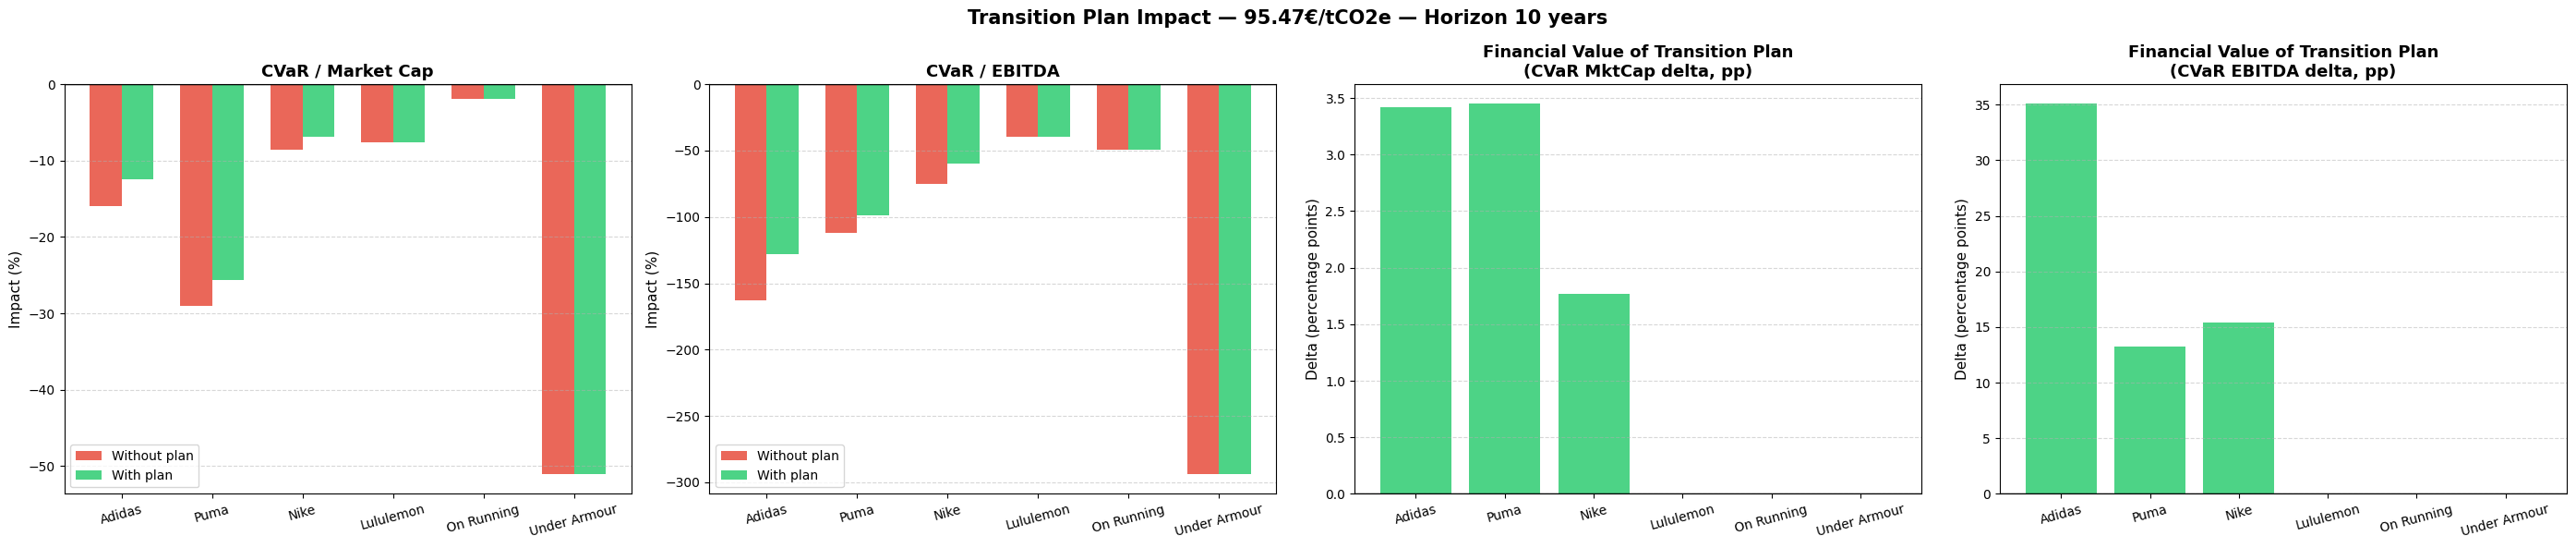

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(28, 6))
x = np.arange(len(results_comparison['Name']))
width = 0.35

# Panel 1: CVaR Market Cap
axes[0].bar(x - width/2, results_comparison['CVaR_MktCap_NoPlan'],
            width, label='Without plan', color='#e74c3c', alpha=0.85)
axes[0].bar(x + width/2, results_comparison['CVaR_MktCap_WithPlan'],
            width, label='With plan', color='#2ecc71', alpha=0.85)
axes[0].set_title('CVaR / Market Cap', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Impact (%)', fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_comparison['Name'], rotation=15)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Panel 2: CVaR EBITDA
axes[1].bar(x - width/2, results_comparison['CVaR_EBITDA_NoPlan'],
            width, label='Without plan', color='#e74c3c', alpha=0.85)
axes[1].bar(x + width/2, results_comparison['CVaR_EBITDA_WithPlan'],
            width, label='With plan', color='#2ecc71', alpha=0.85)
axes[1].set_title('CVaR / EBITDA', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Impact (%)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_comparison['Name'], rotation=15)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Panel 3: Delta MktCap
couleurs_delta_mkt = ['#2ecc71' if v > 0 else '#e74c3c' for v in results_comparison['Delta_MktCap']]
axes[2].bar(results_comparison['Name'], results_comparison['Delta_MktCap'],
            color=couleurs_delta_mkt, alpha=0.85)
axes[2].set_title('Financial Value of Transition Plan\n(CVaR MktCap delta, pp)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Delta (percentage points)', fontsize=11)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

# Panel 4: Delta EBITDA
couleurs_delta_ebitda = ['#2ecc71' if v > 0 else '#e74c3c' for v in results_comparison['Delta_EBITDA']]
axes[3].bar(results_comparison['Name'], results_comparison['Delta_EBITDA'],
            color=couleurs_delta_ebitda, alpha=0.85)
axes[3].set_title('Financial Value of Transition Plan\n(CVaR EBITDA delta, pp)',
                  fontsize=13, fontweight='bold')
axes[3].set_ylabel('Delta (percentage points)', fontsize=11)
axes[3].axhline(0, color='black', linewidth=1)
axes[3].tick_params(axis='x', rotation=15)
axes[3].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(
    f'Transition Plan Impact — {CARBON_PRICE_TARGET}€/tCO2e — Horizon {HORIZON} years',
    fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [6]:
def calculate_cvar_audit_total(row):
    try:
        tk = yf.Ticker(row['Ticker'])
        info = tk.info

        sector = info.get('sector', 'Unknown')
        currency = info.get('currency', 'USD')
        conversion_rate = CURRENCY_TO_EUR.get(currency, 0.855)

        ebitda_override = row.get('EBITDA_Override', None)
        if pd.notna(ebitda_override) and ebitda_override > 0:
            ebitda = ebitda_override
        else:
            ebitda = info.get('ebitda', 0) * conversion_rate

        mkt_cap = info.get('marketCap', 0) * conversion_rate

        if ebitda == 0 or mkt_cap == 0:
            return pd.Series([sector, ebitda, mkt_cap, 0, 0, 0, 0, 0, None, None, None, None])

        # A. Risk Calculation
        emissions = row['Scope_1_2'] + row['Scope_3']
        gross_carbon_cost = emissions * (CARBON_PRICE_TARGET - CARBON_PRICE_BASE)
        net_carbon_cost = gross_carbon_cost * (1 - row['Pass_Through'])

        # B. Opportunity Calculation
        annual_upside = ebitda * row['%_of_Green_Revenue'] * GREEN_MARKET_GROWTH

        # C. Net Cash Flow and Discounting
        delta_cf = annual_upside - net_carbon_cost
        wacc = calculate_wacc(info, conversion_rate)
        vp_impact = sum([delta_cf / ((1 + wacc)**t) for t in range(1, HORIZON + 1)])

        # D. Final Scores
        cvar_score_mktcap = (vp_impact / mkt_cap) * 100
        cvar_score_ebitda = (vp_impact / ebitda) * 100

        # E. Complementary Indicators
        revenues = info.get('totalRevenue', 0)
        revenues = revenues * conversion_rate if revenues > 0 else 0
        carbon_intensity = round((emissions / (revenues / 1e6)), 2) if revenues > 0 else None
        debt = info.get('totalDebt', 0) * conversion_rate
        debt_ebitda_ratio = round(debt / ebitda, 2) if ebitda > 0 else None

        return pd.Series([sector, ebitda, mkt_cap, round(wacc, 4), gross_carbon_cost, net_carbon_cost, annual_upside, delta_cf, vp_impact, round(cvar_score_mktcap, 2), round(cvar_score_ebitda, 2), carbon_intensity, debt_ebitda_ratio])

    except Exception as e:
        return pd.Series(['Error', 0, 0, 0, 0, 0, 0, 0, None, None, None, None, None])

# Apply to dataframe
cols_audit = ['Sector', 'EBITDA', 'Market_Cap', 'WACC', 'gross_carbon_cost', 'net_carbon_cost', 'Green_Upside', 'Delta_CF', 'Cumulative_Impact', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA', 'carbon_intensity', 'debt_ebitda_ratio']
df_companies[cols_audit] = df_companies.apply(calculate_cvar_audit_total, axis=1)

In [7]:
def generate_expert_audit_report(df):
    ordre_lecture = [
        'Name', 'Ticker', 'Sector', 'Scope_1_2', 'Scope_3',
        'carbon_intensity', 'debt_ebitda_ratio',
        'EBITDA', 'Market_Cap', 'gross_carbon_cost', 'Pass_Through',
        'net_carbon_cost', '%_of_Green_Revenue', 'Green_Upside',
        'Delta_CF', 'WACC', 'Cumulative_Impact',
        'CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
        'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
        'Delta_MktCap', 'Delta_EBITDA'
    ]
    cols_finales = [c for c in ordre_lecture if c in df.columns]
    df_trie = df[cols_finales].sort_values(by='CVaR_MktCap_NoPlan', ascending=False)
    return df_trie.style\
        .set_caption("Detailled Data : from CO2e to CVaR scores")\
        .format({
            'Scope_1_2': '{:,.0f} t',
            'Scope_3': '{:,.0f} t',
            'EBITDA': lambda x: f"{x/1e6:,.0f} M€",
            'Market_Cap': lambda x: f"{x/1e9:,.1f} Md€",
            'gross_carbon_cost': lambda x: f"-{x/1e6:,.1f} M€",
            'net_carbon_cost': lambda x: f"-{x/1e6:,.1f} M€",
            'Green_Upside': lambda x: f"+{x/1e6:,.1f} M€",
            'Delta_CF': lambda x: f"{x/1e6:,.1f} M€",
            'Cumulative_Impact': lambda x: f"{x/1e6:,.1f} M€",
            'Pass_Through': '{:.0%}',
            '%_of_Green_Revenue': '{:.0%}',
            'WACC': '{:.1%}',
            'CVaR_MktCap_NoPlan': '{:+.2f}%',
            'CVaR_EBITDA_NoPlan': '{:+.2f}%',
            'CVaR_MktCap_WithPlan': '{:+.2f}%',
            'CVaR_EBITDA_WithPlan': '{:+.2f}%',
            'Delta_MktCap': '{:+.2f} pp',
            'Delta_EBITDA': '{:+.2f} pp',
            'carbon_intensity': '{:,.1f} tCO2e/M€CA',
            'debt_ebitda_ratio': '{:.1f}x',
        })\
        .map(lambda v: f'color: {"#d65f5f" if v < 0 else "#5fba7d"}; font-weight: bold',
             subset=['CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
                     'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
                     'Delta_MktCap', 'Delta_EBITDA'])\
        .set_properties(**{'text-align': 'right', 'font-size': '12px'})\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '10px')]}
        ])

print("✅ Generating final audit table...")
df_audit = df_companies.merge(
    results_comparison[['Name', 'Ticker', 'CVaR_MktCap_NoPlan', 'CVaR_EBITDA_NoPlan',
                         'CVaR_MktCap_WithPlan', 'CVaR_EBITDA_WithPlan',
                         'Delta_MktCap', 'Delta_EBITDA']],
    on=['Name', 'Ticker'],
    how='left'
)
generate_expert_audit_report(df_audit)

✅ Generating final audit table...


,Name,Ticker,Sector,Scope_1_2,Scope_3,carbon_intensity,debt_ebitda_ratio,EBITDA,Market_Cap,gross_carbon_cost,Pass_Through,net_carbon_cost,%_of_Green_Revenue,Green_Upside,Delta_CF,WACC,Cumulative_Impact,CVaR_MktCap_NoPlan,CVaR_EBITDA_NoPlan,CVaR_MktCap_WithPlan,CVaR_EBITDA_WithPlan,Delta_MktCap,Delta_EBITDA
4,On Running,ONON,Consumer Cyclical,"2,571 t","440,233 t",165.3 tCO2e/M€CA,1.2x,401 M€,10.5 Md€,-42.3 M€,0%,-42.3 M€,0%,+0.0 M€,-42.3 M€,12.8%,-231.1 M€,-1.88%,-49.42%,-1.88%,-49.42%,+0.00 pp,+0.00 pp
3,Lululemon,LULU,Consumer Cyclical,"39,834 t","1,608,150 t",172.9 tCO2e/M€CA,0.7x,"2,324 M€",12.2 Md€,-157.3 M€,0%,-157.3 M€,0%,+0.0 M€,-157.3 M€,7.6%,"-1,073.6 M€",-7.56%,-39.66%,-7.56%,-39.66%,+0.00 pp,+0.00 pp
2,Nike,NKE,Consumer Cyclical,"268,712 t","8,186,965 t",211.7 tCO2e/M€CA,1.6x,"6,117 M€",53.4 Md€,-807.3 M€,0%,-807.3 M€,0%,+0.0 M€,-807.3 M€,8.2%,"-5,361.1 M€",-8.62%,-75.24%,-6.85%,-59.82%,+1.77 pp,+15.42 pp
0,Adidas,ADS.DE,Consumer Cyclical,"187,591 t","6,236,869 t",254.4 tCO2e/M€CA,2.4x,"2,492 M€",25.5 Md€,-613.3 M€,0%,-613.3 M€,0%,+0.0 M€,-613.3 M€,8.3%,"-4,062.3 M€",-15.90%,-163.05%,-12.48%,-127.96%,+3.42 pp,+35.09 pp
1,Puma,PUM.DE,Consumer Cyclical,"46,498 t","1,515,367 t",217.8 tCO2e/M€CA,3.0x,971 M€,3.7 Md€,-149.1 M€,0%,-149.1 M€,0%,+0.0 M€,-149.1 M€,6.2%,"-1,088.2 M€",-29.08%,-112.10%,-25.63%,-98.82%,+3.45 pp,+13.28 pp
5,Under Armour,UAA,Consumer Cyclical,"37,327 t","1,664,398 t",399.1 tCO2e/M€CA,5.1x,324 M€,1.9 Md€,-162.5 M€,0%,-162.5 M€,0%,+0.0 M€,-162.5 M€,7.6%,"-1,109.6 M€",-51.08%,-294.01%,-51.08%,-294.01%,+0.00 pp,+0.00 pp
